Kallumadi, S. & Grer, F. (2018). Drug Reviews (Druglib.com) [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55G6J.

In [1]:
import numpy as np
import pandas as pd
from google.colab import drive
drive.mount('/content/drive/')
df_sentiment = pd.read_csv("/content/drive/MyDrive/taodigital/dataset/drugLibTrain_raw.tsv", delimiter="\t")
df_test = pd.read_csv("/content/drive/MyDrive/taodigital/dataset/drugLibTest_raw.tsv", delimiter="\t")
df_sentiment.head(5)

Mounted at /content/drive/


,Unnamed: 0,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ..."
1,3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest..."
2,1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...
3,3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...
4,1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above


/tmp/ipython-input-3-712786977.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df_sentiment, palette='viridis')


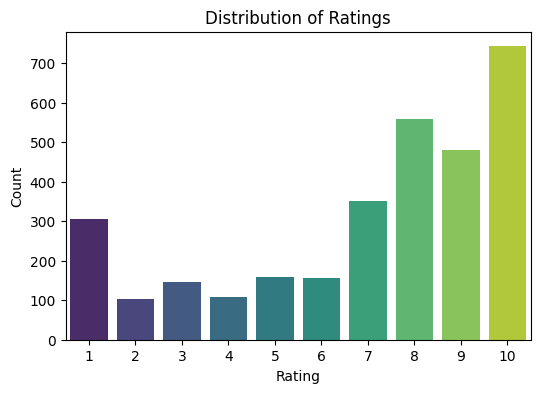

In [3]:
# prompt: plot df_sentiment["rating"] distribution

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='rating', data=df_sentiment, palette='viridis')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

# Data Preprocessing

In [ ]:
# Binning function as in paper
def bin_rating(r):
    r = int(r)
    if r <= 4: return -1  # Negative
    elif r <= 6: return 0  # Neutral
    else: return 1  # Positive

# Apply to train/test sets
df_sentiment['rating_bin'] = df_sentiment['rating'].apply(bin_rating)
df_test['rating_bin'] = df_test['rating'].apply(bin_rating)


# Combine all text columns as in the paper
for df in [df_sentiment, df_test]:
    df['all_reviews'] = (
        df['benefitsReview'].astype(str) + ' ' +
        df['sideEffectsReview'].astype(str) + ' ' +
        df['commentsReview'].astype(str)
    )

Rating bin:

low = 1-4 (-1)

neutral = 5-6 (0)

high = 7-10 (1)

# Classical NLP Approach

In [ ]:
# Prepare data
X_train = df_sentiment['all_reviews']
y_train = df_sentiment['rating_bin']
X_test = df_test['all_reviews']
y_test = df_test['rating_bin']

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score

# CountVectorizer for n-grams (see paper)
vectorizer = CountVectorizer(ngram_range=(1,3), lowercase=True, token_pattern=r'\b\w+\b')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Logistic Regression with class weighting
clf = LogisticRegression(class_weight='balanced', max_iter=500, solver='lbfgs')
clf.fit(X_train_vec, y_train)
y_pred = clf.predict(X_test_vec)

# Evaluation
print("Classification report:")
print(classification_report(y_test, y_pred, digits=4))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))
print("Cohen's Kappa:", cohen_kappa_score(y_test, y_pred))


Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Classification report:
              precision    recall  f1-score   support

          -1     0.6904    0.5643    0.6210       241
           0     0.4138    0.0960    0.1558       125
           1     0.7667    0.9269    0.8392       670

    accuracy                         0.7423      1036
   macro avg     0.6236    0.5291    0.5387      1036
weighted avg     0.7063    0.7423    0.7060      1036

Confusion matrix:
[[136   4 101]
 [ 25  12  88]
 [ 36  13 621]]
Cohen's Kappa: 0.423116869032772


# BERT-based Approach

In [ ]:
from datasets import Dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample

# --- Aggressive upsampling to balance classes ---
df_high = df_sentiment[df_sentiment['rating_bin'] == 1]
df_neu  = df_sentiment[df_sentiment['rating_bin'] == 0]
df_low  = df_sentiment[df_sentiment['rating_bin'] == -1]

max_n = max(len(df_high), len(df_neu), len(df_low))
df_high_up = resample(df_high, replace=True, n_samples=max_n, random_state=42)
df_neu_up  = resample(df_neu,  replace=True, n_samples=max_n, random_state=42)
df_low_up  = resample(df_low,  replace=True, n_samples=max_n, random_state=42)

df_balanced = pd.concat([df_high_up, df_neu_up, df_low_up])
print("Balanced train set:", df_balanced['rating_bin'].value_counts())

# --- Prepare texts and labels ---
train_texts = df_balanced['all_reviews'].tolist()
train_labels = df_balanced['rating_bin'].tolist()
test_texts = df_test['all_reviews'].tolist()
test_labels = df_test['rating_bin'].tolist()

le = LabelEncoder()
le.fit([-1, 0, 1])
y_train = le.transform(train_labels)
y_test = le.transform(test_labels)

In [ ]:
# --- Hugging Face Dataset and Tokenization ---
from transformers import AutoTokenizer

train_ds = Dataset.from_dict({'text': train_texts, 'label': y_train})
test_ds = Dataset.from_dict({'text': test_texts, 'label': y_test})

model_name = "emilyalsentzer/Bio_ClinicalBERT"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_fn(batch):
    return tokenizer(batch['text'], truncation=True, padding='max_length', max_length=128)

train_ds = train_ds.map(tokenize_fn, batched=True)
test_ds = test_ds.map(tokenize_fn, batched=True)

train_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

In [ ]:
# ---Optional: Compute class weights (not strictly needed after perfect balance) ---

from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)

In [ ]:
# --- Custom Trainer with class weights (still helps for noisy minority class) ---
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from torch.nn import CrossEntropyLoss

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = CrossEntropyLoss(weight=class_weights_tensor.to(logits.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

training_args = TrainingArguments(
    output_dir="./results",
    do_eval = True,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    fp16=True,
    logging_steps=10,
    save_strategy="epoch",
    report_to="none"
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    tokenizer=tokenizer,
)

trainer.train()

Balanced train set: rating_bin
 1    2130
 0    2130
-1    2130
Name: count, dtype: int64


Map:   0%|          | 0/6390 [00:00<?, ? examples/s]

Map:   0%|          | 0/1036 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-23-2003620855.py:100: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  trainer = WeightedTrainer(


Step,Training Loss
10,1.189000
20,1.127000
30,1.090900
40,1.108200
50,1.095200
60,1.090500
70,1.113200
80,1.046600
90,1.016700
100,0.930000


Classification report:
              precision    recall  f1-score   support

         Low     0.6784    0.5602    0.6136       241
     Neutral     0.2101    0.2320    0.2205       125
        High     0.8140    0.8493    0.8313       670

    accuracy                         0.7075      1036
   macro avg     0.5675    0.5471    0.5551      1036
weighted avg     0.7096    0.7075    0.7069      1036

Confusion matrix:
[[135  45  61]
 [ 27  29  69]
 [ 37  64 569]]
Cohen's Kappa: 0.418427181120393


In [ ]:
# --- Evaluate ---
pred = trainer.predict(test_ds)
y_pred = pred.predictions.argmax(axis=1)
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
print("Classification report:")
print(classification_report(y_test, y_pred, digits=4, target_names=['Low', 'Neutral', 'High']))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))
print("Cohen's Kappa:", cohen_kappa_score(y_test, y_pred))


Classification report:
              precision    recall  f1-score   support

         Low     0.6784    0.5602    0.6136       241
     Neutral     0.2101    0.2320    0.2205       125
        High     0.8140    0.8493    0.8313       670

    accuracy                         0.7075      1036
   macro avg     0.5675    0.5471    0.5551      1036
weighted avg     0.7096    0.7075    0.7069      1036

Confusion matrix:
[[135  45  61]
 [ 27  29  69]
 [ 37  64 569]]
Cohen's Kappa: 0.418427181120393


In [ ]:
# Copy from logistic regression to ease comparison
print("Classification report:")
print(classification_report(y_test, y_pred, digits=4))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))
print("Cohen's Kappa:", cohen_kappa_score(y_test, y_pred))


Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Classification report:
              precision    recall  f1-score   support

          -1     0.6904    0.5643    0.6210       241
           0     0.4138    0.0960    0.1558       125
           1     0.7667    0.9269    0.8392       670

    accuracy                         0.7423      1036
   macro avg     0.6236    0.5291    0.5387      1036
weighted avg     0.7063    0.7423    0.7060      1036

Confusion matrix:
[[136   4 101]
 [ 25  12  88]
 [ 36  13 621]]
Cohen's Kappa: 0.423116869032772
